# Retriever Goldilocks: A Fresh, Comprehensive Retriever Config Search

Follow-up to `04_retriever_optimization.ipynb` and `05_retriever_optimization_full.ipynb`,
and a sibling to `11_chunking_goldilocks.ipynb`. Applies the same fix to the retriever
question that `11` applied to chunking:

1. **`04`/`05` scored on 5 unlucky, non-fixed samples per config**, with judge failures
   silently dropped -- exactly the noise problem `11`'s audit called out for chunking.
2. **`04`/`05` optimized on Context Relevance alone.** `04`'s "winner" (Similarity k=12,
   CR 0.1595) had middling Adherence; `05`'s winner (Dense MMR, CR 0.0950) wasn't compared
   against BM25/hybrid on the same footing since only 4 of the paper's 8 methods actually
   ran.
3. **Method, `k`, and method-specific parameters (MMR's `lambda_mult`, hybrid's `alpha`)
   were never swept independently** -- `04` varied method and k together (R1..R6), `05`
   fixed every method's own tuning knob at one arbitrary value.
4. **Both notebooks built their retriever on top of unvalidated chunking** (96t token
   chunks in `04`, 192t semantic chunks in `05`) instead of `11`'s actual winning
   configuration.

This notebook fixes what's fixable in a single sitting: (1)/(2) by fixing one 20-question
evaluation set up front, retrying failed judge annotations, and scoring on the same
documented composite used in `11` (not Relevance alone); (3) by running a proper
three-phase search (retrieval method -> k -> method-specific parameter), each phase
isolating one variable; (4) by building every retriever on top of `11`'s actual winning
chunking config (sentence-level chunking + metadata heading, 64-token target, 10% overlap)
instead of an arbitrary chunk size.

Embedding model and generator/judge models are still held constant -- flagged explicitly
in the caveats at the end rather than silently ignored.


## Step 1: Install Dependencies

In [1]:
!pip install -q python-dotenv datasets tiktoken langchain-core langchain-text-splitters langchain-huggingface langchain-chroma langchain-openai nltk matplotlib rank-bm25


[notice] A new release of pip is available: 25.2 -> 26.2
[notice] To update, run: pip install --upgrade pip


## Step 2: Imports & Setup

In [2]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from rank_bm25 import BM25Okapi
from langchain_core.documents import Document
from langchain_chroma import Chroma
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

load_dotenv()
openrouter_token = os.environ.get("OPENROUTER_TOKEN")

import sys


def _add_ragbench_lib_to_path():
    for candidate in (os.getcwd(), os.path.join(os.getcwd(), "delucion_dataset")):
        if os.path.isdir(os.path.join(candidate, "ragbench_lib")) and candidate not in sys.path:
            sys.path.insert(0, candidate)
            return


_add_ragbench_lib_to_path()

from ragbench_lib.data_loading import load_rag_bench_data
from ragbench_lib.models import get_embedding_model, get_generation_llm, get_judge_llm
from ragbench_lib.generation_prompt import RAG_GENERATION_PROMPT
from ragbench_lib.vector_store import get_persist_dir, vector_store_names
from ragbench_lib.chunking import count_tokens, get_sentences
from ragbench_lib.trace_eval import (
    annotate_response_for_metrics_with_retry,
    compute_context_relevance,
    compute_utilization,
    compute_completeness,
    compute_adherence,
)

print("✓ All imports successful")


/Users/saikrishna/Desktop/Codespace/IIIT_AI_ML_course/Capstone_Project/reliablerag/.venv-1/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ All imports successful


## Step 3: Load Dataset (fixed evaluation set)

`EVAL_SAMPLE_SIZE` questions are chosen **once**, up front, and reused for every single
config below -- Phase 1, 2, and 3 all score against the exact same questions, so
differences between configs reflect the retriever choice, not sampling luck. Same
mechanism `11_chunking_goldilocks.ipynb` used for chunking.

In [3]:
DATASET_NAME = "delucionqa"  # feeds load_rag_bench_data() and vector store naming
EVAL_SAMPLE_SIZE = 20        # fixed across every config in this notebook

print("Loading dataset...")
docs_df = load_rag_bench_data(DATASET_NAME, num_samples=max(EVAL_SAMPLE_SIZE + 10, 30))
print(f"✓ Loaded {len(docs_df)} documents from {docs_df['row_id'].nunique()} unique questions")

eval_questions_df = docs_df.drop_duplicates(subset=["row_id"]).head(EVAL_SAMPLE_SIZE).reset_index(drop=True)
print(f"✓ Fixed evaluation set: {len(eval_questions_df)} unique questions (reused for every config below)")


Loading dataset...
✓ Loaded 90 documents from 30 unique questions
✓ Fixed evaluation set: 20 unique questions (reused for every config below)


## Step 4: Models

In [4]:
embedding_model = get_embedding_model(openrouter_token)
llm = get_generation_llm(openrouter_token)
llama_judge = get_judge_llm(openrouter_token)
prompt = RAG_GENERATION_PROMPT

print("✓ Embedding model, generator, and judge configured")


✓ Embedding model, generator, and judge configured


## Step 5: Fixed Chunking Foundation

Every retriever config below is built on `11_chunking_goldilocks.ipynb`'s winning chunking
configuration -- **sentence-level chunking with a metadata heading, 64-token target, 10%
overlap** (composite 0.556, the best of 16 configs tested across method/size/overlap
sweeps) -- instead of the arbitrary 96t/192t chunk sizes `04`/`05` used. This notebook's
independent variable is the retriever, not the chunker, so the chunking layer is held
fixed at its own best-known config.

In [5]:
CHUNK_TARGET_TOKENS = 64
CHUNK_OVERLAP_FRACTION = 0.10


def sentence_level_chunks(docs_df, target_tokens=64, overlap_fraction=0.1):
    """Group whole sentences up to target_tokens; overlap carries the last
    overlap_fraction of each chunk's sentences into the next chunk."""
    documents = []
    for _, doc in docs_df.iterrows():
        sentences = get_sentences(doc["text"])
        if not sentences:
            continue
        sent_tokens = [count_tokens(s) for s in sentences]
        n = len(sentences)
        i, chunk_idx = 0, 0
        while i < n:
            chunk_sents, chunk_tok_count, j = [], 0, i
            while j < n and (not chunk_sents or chunk_tok_count + sent_tokens[j] <= target_tokens):
                chunk_sents.append(sentences[j])
                chunk_tok_count += sent_tokens[j]
                j += 1
            chunk_text = " ".join(chunk_sents)
            documents.append(Document(
                page_content=chunk_text,
                metadata={
                    "chunk_id": f"{doc['doc_id']}_sent{chunk_idx}",
                    "row_id": doc["row_id"],
                    "tokens": count_tokens(chunk_text),
                },
            ))
            chunk_idx += 1
            overlap_count = int(len(chunk_sents) * overlap_fraction)
            step = max(len(chunk_sents) - overlap_count, 1)
            i += step
    return documents


def metadata_enhanced_chunks(docs_df, target_tokens=64, overlap_fraction=0.1):
    """Sentence-level chunks with a lightweight heading prepended (each source
    document's first sentence, used as a cheap proxy title)."""
    documents = sentence_level_chunks(docs_df, target_tokens=target_tokens, overlap_fraction=overlap_fraction)

    doc_id_to_heading = {}
    for _, doc in docs_df.iterrows():
        sentences = get_sentences(doc["text"])
        heading = sentences[0] if sentences else doc["text"][:80]
        doc_id_to_heading[doc["doc_id"]] = " ".join(heading.split()[:12])

    enhanced = []
    for d in documents:
        source_doc_id = d.metadata["chunk_id"].rsplit("_sent", 1)[0]
        heading = doc_id_to_heading.get(source_doc_id, "")
        new_text = f"[Context: {heading}]\n{d.page_content}"
        enhanced.append(Document(
            page_content=new_text,
            metadata={**d.metadata, "tokens": count_tokens(new_text)},
        ))
    return enhanced


print("Building fixed chunking foundation (sentence + metadata, 64t, 10% overlap)...")
documents = metadata_enhanced_chunks(docs_df, target_tokens=CHUNK_TARGET_TOKENS, overlap_fraction=CHUNK_OVERLAP_FRACTION)
print(f"✓ Built {len(documents)} chunks, avg {np.mean([d.metadata['tokens'] for d in documents]):.0f} tokens/chunk")


Building fixed chunking foundation (sentence + metadata, 64t, 10% overlap)...
✓ Built 456 chunks, avg 68 tokens/chunk


## Step 6: Retriever Implementations

Four retrieval strategies from the paper's search space, each exposing the parameter this
notebook sweeps once its phase comes up:

- **similarity** -- plain dense cosine similarity (no extra tunable parameter beyond `k`)
- **mmr** -- dense retrieval with Maximal Marginal Relevance (`lambda_mult`: 1.0 = pure
  relevance, 0.0 = pure diversity)
- **bm25** -- sparse lexical retrieval (no extra tunable parameter beyond `k`)
- **hybrid** -- BM25 + dense, linearly combined (`alpha`: weight on the BM25 side, so
  `alpha=1.0` is pure BM25 and `alpha=0.0` is pure dense)

All four take `documents` (the fixed chunking foundation above) and share a `.retrieve(query)`
interface so the evaluation runner in Step 7 can treat them identically.

In [6]:
class SimilarityRetriever:
    """Plain dense cosine similarity search."""

    def __init__(self, documents, embedding_model, k=8, config_name="sim"):
        self.k = k
        prefix, collection_name = vector_store_names(DATASET_NAME, config_name)
        persist_dir = get_persist_dir(prefix)
        self.vector_store = Chroma.from_documents(
            documents=documents, embedding=embedding_model,
            collection_name=collection_name, persist_directory=persist_dir,
        )

    def retrieve(self, query):
        return self.vector_store.as_retriever(
            search_type="similarity", search_kwargs={"k": self.k}
        ).invoke(query)


class MMRRetriever:
    """Dense retrieval with Maximal Marginal Relevance -- balances relevance & diversity."""

    def __init__(self, documents, embedding_model, k=8, lambda_mult=0.5, config_name="mmr"):
        self.k = k
        self.lambda_mult = lambda_mult
        prefix, collection_name = vector_store_names(DATASET_NAME, config_name)
        persist_dir = get_persist_dir(prefix)
        self.vector_store = Chroma.from_documents(
            documents=documents, embedding=embedding_model,
            collection_name=collection_name, persist_directory=persist_dir,
        )

    def retrieve(self, query):
        return self.vector_store.as_retriever(
            search_type="mmr",
            search_kwargs={"k": self.k, "lambda_mult": self.lambda_mult},
        ).invoke(query)


class BM25Retriever:
    """Sparse lexical retrieval baseline -- no embedding calls at query time."""

    def __init__(self, documents, k=8, **_ignored):
        self.k = k
        self.documents = documents
        tokenized = [d.page_content.split() for d in documents]
        self.bm25 = BM25Okapi(tokenized)

    def retrieve(self, query):
        scores = self.bm25.get_scores(query.split())
        top_indices = np.argsort(scores)[-self.k:][::-1]
        return [self.documents[i] for i in top_indices]


class HybridRetriever:
    """BM25 + dense similarity, linearly combined after min-max normalizing each side.
    `alpha` is the weight on BM25; `(1 - alpha)` is the weight on the normalized dense score."""

    def __init__(self, documents, embedding_model, k=8, alpha=0.5, config_name="hybrid"):
        self.k = k
        self.alpha = alpha
        self.documents = documents
        tokenized = [d.page_content.split() for d in documents]
        self.bm25 = BM25Okapi(tokenized)

        prefix, collection_name = vector_store_names(DATASET_NAME, config_name)
        persist_dir = get_persist_dir(prefix)
        self.vector_store = Chroma.from_documents(
            documents=documents, embedding=embedding_model,
            collection_name=collection_name, persist_directory=persist_dir,
        )

    def retrieve(self, query):
        bm25_scores = np.array(self.bm25.get_scores(query.split()), dtype=float)
        if np.max(bm25_scores) > np.min(bm25_scores):
            bm25_scores = (bm25_scores - np.min(bm25_scores)) / (np.max(bm25_scores) - np.min(bm25_scores))
        else:
            bm25_scores = np.ones_like(bm25_scores) / max(len(bm25_scores), 1)

        dense_results = self.vector_store.similarity_search_with_score(query, k=len(self.documents))
        dense_score_by_content = {}
        if dense_results:
            raw = np.array([score for _, score in dense_results], dtype=float)
            if np.max(raw) > np.min(raw):
                norm = 1.0 - (raw - np.min(raw)) / (np.max(raw) - np.min(raw))
            else:
                norm = np.ones_like(raw)
            for (doc, _), score in zip(dense_results, norm):
                dense_score_by_content[doc.page_content] = score

        combined = np.array([
            self.alpha * bm25_scores[i] + (1 - self.alpha) * dense_score_by_content.get(d.page_content, 0.0)
            for i, d in enumerate(self.documents)
        ])
        top_indices = np.argsort(combined)[-self.k:][::-1]
        return [self.documents[i] for i in top_indices]


print("✓ Retriever implementations ready (similarity, mmr, bm25, hybrid)")


✓ Retriever implementations ready (similarity, mmr, bm25, hybrid)


## Step 7: Evaluation Runner

One function used by every phase below: builds/wraps a retriever, runs the fixed question
set through it, retries failed judge annotations instead of dropping them, and reports both
raw TRACe metrics and the same documented composite score `11_chunking_goldilocks.ipynb`
used.

**Composite score = 0.35·Relevance + 0.15·Utilization + 0.15·Completeness + 0.35·Adherence**
(identical weighting to `11`, for direct comparability -- Relevance and Adherence weighted
highest since they carry the most direct practical consequence: how much irrelevant text
the retriever hands over, and how often the generator hallucinates as a result).

In [7]:
def evaluate_retriever_config(config_name, retriever, eval_questions_df, max_annotate_attempts=3):
    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)

    rag_chain = (
        {"context": lambda q: format_docs(retriever.retrieve(q)), "question": lambda q: q}
        | prompt | llm | StrOutputParser()
    )

    per_sample = []
    n_failed = 0
    retrieved_counts = []
    for _, row in eval_questions_df.iterrows():
        question = row["question"]
        try:
            response = rag_chain.invoke(question)
            retrieved_docs = retriever.retrieve(question)
            retrieved_texts = [d.page_content for d in retrieved_docs]
            retrieved_counts.append(len(retrieved_texts))
            annotation = annotate_response_for_metrics_with_retry(
                llama_judge, retrieved_texts, question, response, max_attempts=max_annotate_attempts
            )
            if annotation["success"]:
                per_sample.append({
                    "context_relevance": compute_context_relevance(retrieved_texts, annotation),
                    "utilization": compute_utilization(retrieved_texts, annotation),
                    "completeness": compute_completeness(annotation),
                    "adherence": compute_adherence(annotation),
                })
            else:
                n_failed += 1
        except Exception:
            n_failed += 1

    result = {
        "config": config_name,
        "avg_retrieved": round(float(np.mean(retrieved_counts)), 1) if retrieved_counts else 0.0,
        "n_eval": len(per_sample),
        "n_failed": n_failed,
        "context_relevance": np.mean([r["context_relevance"] for r in per_sample]) if per_sample else None,
        "utilization": np.mean([r["utilization"] for r in per_sample]) if per_sample else None,
        "completeness": np.mean([r["completeness"] for r in per_sample]) if per_sample else None,
        "adherence": np.mean([r["adherence"] for r in per_sample]) if per_sample else None,
    }
    if per_sample:
        result["composite"] = (
            0.35 * result["context_relevance"]
            + 0.15 * result["utilization"]
            + 0.15 * result["completeness"]
            + 0.35 * result["adherence"]
        )
    else:
        result["composite"] = None
    return result


print("✓ evaluate_retriever_config defined")


✓ evaluate_retriever_config defined


## Step 8: Phase 1 -- Retrieval Method Comparison (fixed k=8)

Every method below runs at the same `k=8` (the depth `11` and the original paper held
fixed), so this phase isolates **retrieval method**, not depth. MMR and hybrid use their
own default tuning value (`lambda_mult=0.5`, `alpha=0.5`) here -- their own knob gets swept
in Phase 3.

In [8]:
K_PHASE1 = 8

phase1_builders = {
    "similarity": lambda: SimilarityRetriever(documents, embedding_model, k=K_PHASE1, config_name="p1_similarity"),
    "mmr": lambda: MMRRetriever(documents, embedding_model, k=K_PHASE1, lambda_mult=0.5, config_name="p1_mmr"),
    "bm25": lambda: BM25Retriever(documents, k=K_PHASE1),
    "hybrid": lambda: HybridRetriever(documents, embedding_model, k=K_PHASE1, alpha=0.5, config_name="p1_hybrid"),
}

print("=" * 100)
print(f"PHASE 1: RETRIEVAL METHOD COMPARISON @ k={K_PHASE1}, {EVAL_SAMPLE_SIZE} fixed questions")
print("=" * 100)

phase1_results = []
for name, builder in phase1_builders.items():
    print(f"\n--- {name} ---")
    retriever = builder()
    result = evaluate_retriever_config(f"p1_{name}", retriever, eval_questions_df)
    phase1_results.append(result)
    if result["composite"] is not None:
        print(f"  CR={result['context_relevance']:.4f} Util={result['utilization']:.4f} "
              f"Comp={result['completeness']:.4f} Adh={result['adherence']:.4f} "
              f"Composite={result['composite']:.4f}  (failed {result['n_failed']}/{EVAL_SAMPLE_SIZE})")
    else:
        print(f"  ✗ No successful evaluations (failed {result['n_failed']}/{EVAL_SAMPLE_SIZE})")

phase1_df = pd.DataFrame(phase1_results).sort_values("composite", ascending=False, na_position="last")
print("\n" + "=" * 100)
print("PHASE 1 RESULTS (ranked by composite score)")
print("=" * 100)
display(phase1_df)


PHASE 1: RETRIEVAL METHOD COMPARISON @ k=8, 20 fixed questions

--- similarity ---
  CR=0.2882 Util=0.1123 Comp=0.4660 Adh=0.8500 Composite=0.4851  (failed 0/20)

--- mmr ---
  CR=0.2000 Util=0.1213 Comp=0.7233 Adh=0.9500 Composite=0.5292  (failed 0/20)

--- bm25 ---
  CR=0.1641 Util=0.0937 Comp=0.5444 Adh=0.9000 Composite=0.4682  (failed 0/20)

--- hybrid ---
  CR=0.2349 Util=0.1292 Comp=0.6485 Adh=0.9500 Composite=0.5314  (failed 0/20)

PHASE 1 RESULTS (ranked by composite score)


,config,avg_retrieved,n_eval,n_failed,context_relevance,utilization,completeness,adherence,composite
3,p1_hybrid,8.0,20,0,0.234905,0.12924,0.648510,0.95,0.531379
1,p1_mmr,8.0,20,0,0.200015,0.12127,0.723260,0.95,0.529185
0,p1_similarity,8.0,20,0,0.288205,0.11233,0.465970,0.85,0.485117
2,p1_bm25,8.0,20,0,0.164130,0.09374,0.544445,0.90,0.468173


## Step 9: Phase 2 -- Retrieval Depth (`k`) Sweep

Takes Phase 1's winning method and sweeps `k`, holding method (and its own tuning
parameter, at the Phase 1 default) fixed -- isolates **retrieval depth**, unconfounded
with method choice. This is the interaction `11_chunking_goldilocks.ipynb` explicitly
flagged as out of scope (chunk size x k) -- here `k` is finally swept on its own axis.

In [9]:
PHASE2_METHOD_BUILDERS = {
    "similarity": lambda k, cfg: SimilarityRetriever(documents, embedding_model, k=k, config_name=cfg),
    "mmr": lambda k, cfg: MMRRetriever(documents, embedding_model, k=k, lambda_mult=0.5, config_name=cfg),
    "bm25": lambda k, cfg: BM25Retriever(documents, k=k),
    "hybrid": lambda k, cfg: HybridRetriever(documents, embedding_model, k=k, alpha=0.5, config_name=cfg),
}

phase1_winner = phase1_df.iloc[0]["config"].replace("p1_", "")
builder_fn = PHASE2_METHOD_BUILDERS[phase1_winner]
print(f"Phase 1 winner: {phase1_winner} -- sweeping k next\n")

k_values_to_test = [4, 6, 8, 10, 12, 16]

print("=" * 100)
print(f"PHASE 2: K SWEEP for '{phase1_winner}' retrieval, {EVAL_SAMPLE_SIZE} fixed questions")
print("=" * 100)

phase2_results = []
for k in k_values_to_test:
    print(f"\n--- {phase1_winner} @ k={k} ---")
    retriever = builder_fn(k, f"p2_{phase1_winner}_k{k}")
    result = evaluate_retriever_config(f"p2_{phase1_winner}_k{k}", retriever, eval_questions_df)
    phase2_results.append(result)
    if result["composite"] is not None:
        print(f"  CR={result['context_relevance']:.4f} Adh={result['adherence']:.4f} "
              f"Composite={result['composite']:.4f}  (failed {result['n_failed']}/{EVAL_SAMPLE_SIZE})")
    else:
        print(f"  ✗ No successful evaluations (failed {result['n_failed']}/{EVAL_SAMPLE_SIZE})")

phase2_df = pd.DataFrame(phase2_results).sort_values("composite", ascending=False, na_position="last")
print("\n" + "=" * 100)
print("PHASE 2 RESULTS (ranked by composite score)")
print("=" * 100)
display(phase2_df)


Phase 1 winner: hybrid -- sweeping k next

PHASE 2: K SWEEP for 'hybrid' retrieval, 20 fixed questions

--- hybrid @ k=4 ---
  CR=0.3538 Adh=1.0000 Composite=0.5978  (failed 0/20)

--- hybrid @ k=6 ---
  CR=0.3053 Adh=0.9500 Composite=0.5653  (failed 0/20)

--- hybrid @ k=8 ---
  CR=0.2326 Adh=1.0000 Composite=0.5571  (failed 0/20)

--- hybrid @ k=10 ---
  CR=0.2019 Adh=0.9500 Composite=0.5150  (failed 0/20)

--- hybrid @ k=12 ---
  CR=0.1891 Adh=0.9500 Composite=0.5007  (failed 0/20)

--- hybrid @ k=16 ---
  CR=0.1722 Adh=1.0000 Composite=0.5194  (failed 0/20)

PHASE 2 RESULTS (ranked by composite score)


,config,avg_retrieved,n_eval,n_failed,context_relevance,utilization,completeness,adherence,composite
0,p2_hybrid_k4,4.0,20,0,0.353750,0.205850,0.620825,1.00,0.597814
1,p2_hybrid_k6,6.0,20,0,0.305300,0.186045,0.653610,0.95,0.565303
2,p2_hybrid_k8,8.0,20,0,0.232555,0.141875,0.696270,1.00,0.557116
5,p2_hybrid_k16,16.0,20,0,0.172230,0.083200,0.644045,1.00,0.519367
3,p2_hybrid_k10,10.0,20,0,0.201940,0.111535,0.633680,0.95,0.514961
4,p2_hybrid_k12,12.0,20,0,0.189130,0.100425,0.579365,0.95,0.500664


## Step 10: Phase 3 -- Method-Specific Parameter Sweep

Takes Phase 2's winning `k` and sweeps the winning method's own tuning knob, holding
method and `k` fixed -- isolates **that parameter** from everything else:

- `mmr` -> `lambda_mult` (1.0 = pure relevance ... 0.0 = pure diversity)
- `hybrid` -> `alpha` (1.0 = pure BM25 ... 0.0 = pure dense)
- `similarity` / `bm25` have no extra knob beyond `k` -- if either wins Phase 1, this phase
  falls back to sweeping `mmr`'s `lambda_mult` at the winning `k` instead, so Phase 3 always
  produces a usable parameter recommendation (mirrors `11`'s fallback when its Phase 1
  winner wasn't size-sweepable).

In [10]:
phase2_winner_config = phase2_df.iloc[0]["config"]
phase2_winner_k = int(phase2_winner_config.rsplit("_k", 1)[-1])
print(f"Phase 2 winner k: {phase2_winner_k} -- sweeping method-specific parameter next\n")

PHASE3_PARAM_SWEEPS = {
    "mmr": {
        "param_name": "lambda_mult",
        "values": [0.0, 0.25, 0.5, 0.75, 1.0],
        "build": lambda v, cfg: MMRRetriever(documents, embedding_model, k=phase2_winner_k, lambda_mult=v, config_name=cfg),
    },
    "hybrid": {
        "param_name": "alpha",
        "values": [0.1, 0.3, 0.5, 0.7, 0.9],
        "build": lambda v, cfg: HybridRetriever(documents, embedding_model, k=phase2_winner_k, alpha=v, config_name=cfg),
    },
}

phase3_method = phase1_winner if phase1_winner in PHASE3_PARAM_SWEEPS else "mmr"
if phase3_method != phase1_winner:
    print(f"Phase 1 winner '{phase1_winner}' has no extra tunable parameter beyond k; "
          f"falling back to sweeping mmr's lambda_mult @ k={phase2_winner_k} instead.\n")

sweep = PHASE3_PARAM_SWEEPS[phase3_method]
param_name, param_values, build_fn = sweep["param_name"], sweep["values"], sweep["build"]

print("=" * 100)
print(f"PHASE 3: {param_name.upper()} SWEEP for '{phase3_method}' @ k={phase2_winner_k}, {EVAL_SAMPLE_SIZE} fixed questions")
print("=" * 100)

phase3_results = []
for v in param_values:
    print(f"\n--- {phase3_method} @ k={phase2_winner_k}, {param_name}={v} ---")
    retriever = build_fn(v, f"p3_{phase3_method}_k{phase2_winner_k}_{param_name}{v}")
    result = evaluate_retriever_config(f"p3_{phase3_method}_k{phase2_winner_k}_{param_name}{v}", retriever, eval_questions_df)
    phase3_results.append(result)
    if result["composite"] is not None:
        print(f"  CR={result['context_relevance']:.4f} Adh={result['adherence']:.4f} "
              f"Composite={result['composite']:.4f}  (failed {result['n_failed']}/{EVAL_SAMPLE_SIZE})")
    else:
        print(f"  ✗ No successful evaluations (failed {result['n_failed']}/{EVAL_SAMPLE_SIZE})")

phase3_df = pd.DataFrame(phase3_results).sort_values("composite", ascending=False, na_position="last")
print("\n" + "=" * 100)
print("PHASE 3 RESULTS (ranked by composite score)")
print("=" * 100)
display(phase3_df)


Phase 2 winner k: 4 -- sweeping method-specific parameter next

PHASE 3: ALPHA SWEEP for 'hybrid' @ k=4, 20 fixed questions

--- hybrid @ k=4, alpha=0.1 ---
  CR=0.4418 Adh=0.9500 Composite=0.5925  (failed 0/20)

--- hybrid @ k=4, alpha=0.3 ---
  CR=0.4529 Adh=0.9500 Composite=0.6221  (failed 0/20)

--- hybrid @ k=4, alpha=0.5 ---
  CR=0.3726 Adh=1.0000 Composite=0.6173  (failed 0/20)

--- hybrid @ k=4, alpha=0.7 ---
  CR=0.3520 Adh=0.9474 Composite=0.5703  (failed 1/20)

--- hybrid @ k=4, alpha=0.9 ---
  CR=0.2598 Adh=0.8000 Composite=0.4806  (failed 0/20)

PHASE 3 RESULTS (ranked by composite score)


,config,avg_retrieved,n_eval,n_failed,context_relevance,utilization,completeness,adherence,composite
1,p3_hybrid_k4_alpha0.3,4.0,20,0,0.452920,0.257860,0.616250,0.950000,0.622138
2,p3_hybrid_k4_alpha0.5,4.0,20,0,0.372600,0.241405,0.671425,1.000000,0.617334
0,p3_hybrid_k4_alpha0.1,4.0,20,0,0.441815,0.202585,0.500095,0.950000,0.592537
3,p3_hybrid_k4_alpha0.7,4.0,19,1,0.352037,0.195347,0.574563,0.947368,0.570278
4,p3_hybrid_k4_alpha0.9,4.0,20,0,0.259845,0.156875,0.574165,0.800000,0.480602


## Step 11: Visualize the Sweeps

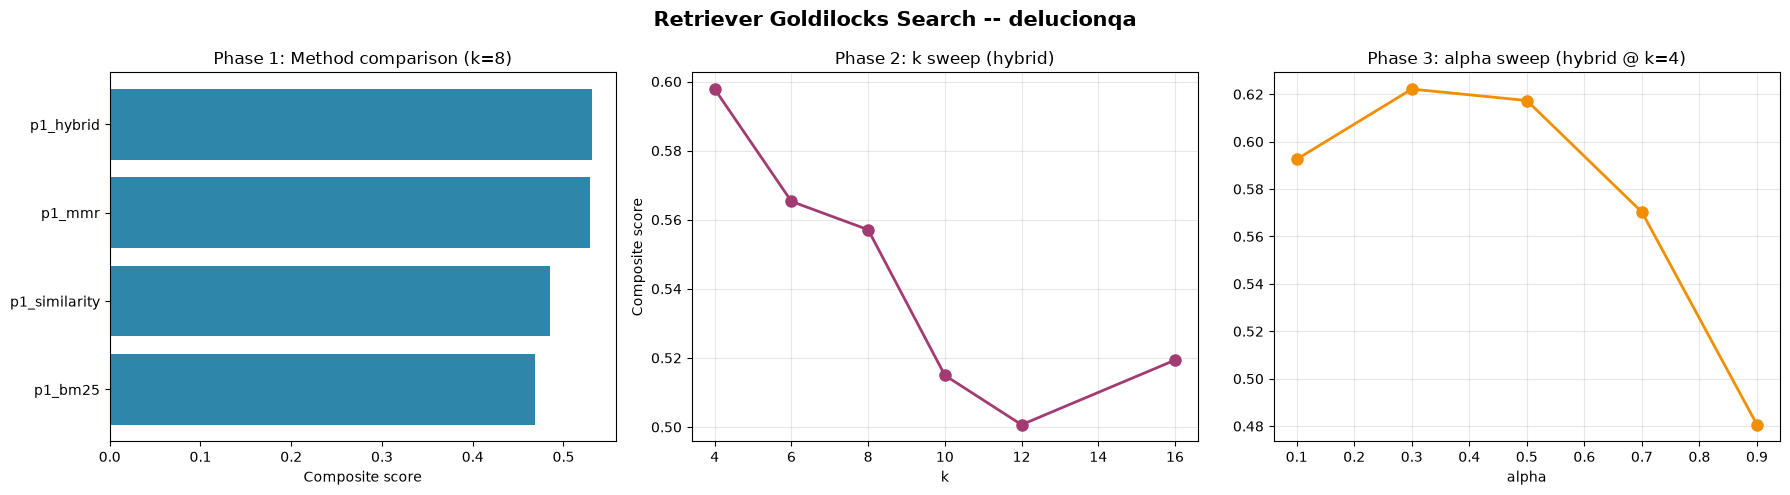

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Retriever Goldilocks Search -- {DATASET_NAME}", fontsize=15, fontweight="bold")

p1_plot = phase1_df.dropna(subset=["composite"]).sort_values("composite")
axes[0].barh(p1_plot["config"], p1_plot["composite"], color="#2E86AB")
axes[0].set_xlabel("Composite score")
axes[0].set_title(f"Phase 1: Method comparison (k={K_PHASE1})")

p2_plot = phase2_df.dropna(subset=["composite"]).copy()
p2_plot["k"] = p2_plot["config"].str.extract(r"_k(\d+)$").astype(int)
p2_plot = p2_plot.sort_values("k")
axes[1].plot(p2_plot["k"], p2_plot["composite"], "o-", color="#A23B72", linewidth=2, markersize=8)
axes[1].set_xlabel("k")
axes[1].set_ylabel("Composite score")
axes[1].set_title(f"Phase 2: k sweep ({phase1_winner})")
axes[1].grid(True, alpha=0.3)

p3_plot = phase3_df.dropna(subset=["composite"]).copy()
p3_plot["param_value"] = p3_plot["config"].str.extract(rf"_{param_name}([0-9.]+)$").astype(float)
p3_plot = p3_plot.sort_values("param_value")
axes[2].plot(p3_plot["param_value"], p3_plot["composite"], "o-", color="#F18F01", linewidth=2, markersize=8)
axes[2].set_xlabel(param_name)
axes[2].set_title(f"Phase 3: {param_name} sweep ({phase3_method} @ k={phase2_winner_k})")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Step 12: Final Recommendation

In [12]:
all_results_df = pd.concat([phase1_df, phase2_df, phase3_df], ignore_index=True)
all_results_df = all_results_df.dropna(subset=["composite"]).sort_values("composite", ascending=False)

print("=" * 100)
print("ALL CONFIGS ACROSS ALL THREE PHASES, RANKED BY COMPOSITE SCORE")
print("=" * 100)
display(all_results_df[[
    "config", "avg_retrieved", "n_eval", "n_failed",
    "context_relevance", "utilization", "completeness", "adherence", "composite",
]])

best = all_results_df.iloc[0]
print("\n" + "=" * 100)
print(f"🏆 GOLDILOCKS RETRIEVER CONFIG: {best['config']}")
print("=" * 100)
print(f"  Avg docs retrieved: {best['avg_retrieved']:.1f}")
print(f"  Context Relevance:  {best['context_relevance']:.4f}")
print(f"  Utilization:        {best['utilization']:.4f}")
print(f"  Completeness:       {best['completeness']:.4f}")
print(f"  Adherence:          {best['adherence']:.4f}")
print(f"  Composite:          {best['composite']:.4f}")
print(f"  Eval sample:        {best['n_eval']}/{EVAL_SAMPLE_SIZE} succeeded (failed: {best['n_failed']})")
print("=" * 100)


ALL CONFIGS ACROSS ALL THREE PHASES, RANKED BY COMPOSITE SCORE


,config,avg_retrieved,n_eval,n_failed,context_relevance,utilization,completeness,adherence,composite
10,p3_hybrid_k4_alpha0.3,4.0,20,0,0.452920,0.257860,0.616250,0.950000,0.622138
11,p3_hybrid_k4_alpha0.5,4.0,20,0,0.372600,0.241405,0.671425,1.000000,0.617334
4,p2_hybrid_k4,4.0,20,0,0.353750,0.205850,0.620825,1.000000,0.597814
12,p3_hybrid_k4_alpha0.1,4.0,20,0,0.441815,0.202585,0.500095,0.950000,0.592537
13,p3_hybrid_k4_alpha0.7,4.0,19,1,0.352037,0.195347,0.574563,0.947368,0.570278
5,p2_hybrid_k6,6.0,20,0,0.305300,0.186045,0.653610,0.950000,0.565303
6,p2_hybrid_k8,8.0,20,0,0.232555,0.141875,0.696270,1.000000,0.557116
0,p1_hybrid,8.0,20,0,0.234905,0.129240,0.648510,0.950000,0.531379
1,p1_mmr,8.0,20,0,0.200015,0.121270,0.723260,0.950000,0.529185
7,p2_hybrid_k16,16.0,20,0,0.172230,0.083200,0.644045,1.000000,0.519367



🏆 GOLDILOCKS RETRIEVER CONFIG: p3_hybrid_k4_alpha0.3
  Avg docs retrieved: 4.0
  Context Relevance:  0.4529
  Utilization:        0.2579
  Completeness:       0.6163
  Adherence:          0.9500
  Composite:          0.6221
  Eval sample:        20/20 succeeded (failed: 0)


### Caveats -- read before treating this as final

- **Still a single run on one fixed 20-question sample.** Retrying failed annotations and
  reusing the same question set across every config removes *some* noise, but this is one
  dataset draw, not a statistically robust estimate. Bump `EVAL_SAMPLE_SIZE` and/or repeat
  with a different fixed sample before locking a config into production.
- **Chunking held constant** at `11_chunking_goldilocks.ipynb`'s winning config (sentence +
  metadata, 64t, 10% overlap). Chunk size and retriever choice interact (e.g. BM25 tends to
  reward larger, keyword-dense chunks differently than dense similarity does) -- not swept
  jointly here.
- **Embedding model held constant** (`openai/text-embedding-3-small`, `ragbench_lib`
  default). Not explored as a variable in this notebook.
- **Query transformation (rewriting, decomposition, HyDE) is out of scope here** -- `05`
  touched on these but never scored them on a fixed sample; that would be a natural next
  notebook in this series, applied on top of whatever retriever config wins here.
- **Composite score weighting (0.35/0.15/0.15/0.35) is a judgment call**, kept identical to
  `11` for comparability. The raw per-metric columns are in every results table if you want
  to re-rank by a different weighting or a single metric.
